

| 섹션 | 논문 대응 | 내용 |
|------|-----------|------|
| §1. 라이브러리 | - | 임포트 + GPU 확인 |
| §2. 데이터 로드 | §3.1 | 4개 데이터셋 + 레이블 매핑 |
| §3. 전처리 | §3.3 / Algorithm 1 | 분할 + 커스텀 토큰 추가 |
| §4. 모델 학습 | §4.2 / Algorithm 1 | KoELECTRA × Dataset 1~4 |
| §5. Table 3 재현 | **Table 3** | 4개 데이터셋 성능 비교 + CSV 저장 |
| §6. 학습 곡선 | **Fig. 14** | Dataset2 기준 시각화 |
| §7. 최적 모델 저장·로드 | - | config 손상 없는 안전한 저장 |
| §8. 단일 분류 평가 | **Fig. 10** | 가상 대화 분류 결과 |
| §9. 다중 분류 | **Fig. 11~13** | 임계치 1/3/5 비교 |
| §10. 인텐트별 F1 | **Table 6** | 클래스별 Precision/Recall/F1 |
| §11. 우울 점수 | 확장 기능 | 수정된 가중 점수 산출 |
| §12. 팀원 공유 가이드 | - | 로드 방법 + Streamlit 구조 |

> ⚠️ **반드시 위에서 아래 순서대로 실행하세요.**

> 💡 §4(학습)는 GPU 필수. 학습 완료 후 §5~§12는 저장된 모델로 바로 실행 가능.


## §1. 라이브러리 임포트 + 환경 설정


In [1]:
# & "c:\Users\asia\anaconda3\envs\pytorch_env\python.exe" -m pip uninstall -y torch torchvision torchaudio

# & "c:\Users\asia\anaconda3\envs\pytorch_env\python.exe" -m pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu121 --no-cache-dir

In [2]:
import torch
# 1. 이제 '2.1.2+cu121'이 출력되어야 합니다.
print(f"현재 인식된 버전: {torch.__version__}") 

# 2. True가 나오는지 확인
print(f"CUDA 사용 가능: {torch.cuda.is_available()}") 

if torch.cuda.is_available():
    # 3. 'NVIDIA GeForce RTX 4060'이 뜨면 끝입니다
    print(f"GPU 장치명: {torch.cuda.get_device_name(0)}")

현재 인식된 버전: 2.1.2+cu121
CUDA 사용 가능: True
GPU 장치명: NVIDIA GeForce RTX 4060


In [3]:
# # 1. transformers를 현재 환경에 맞춰 재설치 (의존성 재정렬)
# & "c:\Users\asia\anaconda3\envs\pytorch_env\python.exe" -m pip install --force-reinstall transformers huggingface-hub tokenizers

In [4]:
# & "c:\Users\asia\anaconda3\envs\pytorch_env\python.exe" -m pip install transformers==4.36.2

In [5]:
import os, json, time, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Patch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
warnings.filterwarnings('ignore')

# 한국어 폰트
if platform.system() == 'Windows':
    rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    rcParams['font.family'] = 'AppleGothic'
else:
    rcParams['font.family'] = 'NanumGothic'
rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'Torch  : {torch.__version__}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  GPU를 찾을 수 없습니다. 학습 속도가 매우 느려질 수 있습니다.')


c:\Users\asia\anaconda3\envs\pytorch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
Torch  : 2.1.2+cu121
GPU    : NVIDIA GeForce RTX 4060


## §2. 데이터 로드
**논문 §3.1** — 4개 데이터셋 + 20개 인텐트 레이블 매핑

| 데이터셋 | 우울 관련 | 일상 | 특징 |
|---------|----------|------|------|
| Dataset 1 | ~19,673 | ~23,000 | 챗봇 + 주제별 |
| **Dataset 2** | **~19,673** | **~18,000** | **주제별만 (논문 최고 성능)** |
| Dataset 3 | ~19,673 | ~1,000 | 주제별 소량 |
| Dataset 4 | ~19,673 | ~6,290 | 챗봇 + 주제별 균형 |


In [7]:
# 20개 인텐트 레이블 매핑 (논문 §3.1 기준)
EMOTION_MAP = {
    '우울감':0,  '슬픔':1,       '외로움':2,    '분노':3,    '무기력':4,
    '감정조절이상':5, '상실감':6, '식욕저하':7,  '식욕증가':8, '불면':9,
    '초조함':10, '일상':11,      '피로':12,     '죄책감':13,  '집중력저하':14,
    '자신감저하':15, '자존감저하':16, '절망감':17, '자살충동':18, '불안':19,
}
INV_MAP = {v: k for k, v in EMOTION_MAP.items()}

# 4개 데이터셋 로드
datasets = {}
for i in range(1, 5):
    path = f'./데이터셋/dataset_{i}.csv'
    try:
        df = pd.read_csv(path)
        if 'label' not in df.columns:
            df['label'] = df['intent'].map(EMOTION_MAP)
        df['label']       = df['label'].astype(int)
        df['is_negative'] = (df['label'] != 11).astype(int)  # 일상=11 → 0(비우울)
        datasets[i] = df
        print(f'✅ Dataset {i}: {len(df):,}행  '
              f'(우울 {df["is_negative"].sum():,} / 일상 {(~df["is_negative"].astype(bool)).sum():,})')
    except FileNotFoundError:
        print(f'❌ Dataset {i}: 파일 없음 ({path})')

print()
display(datasets[2].head(3))


✅ Dataset 1: 42,666행  (우울 19,666 / 일상 23,000)
✅ Dataset 2: 37,666행  (우울 19,666 / 일상 18,000)
✅ Dataset 3: 20,666행  (우울 19,666 / 일상 1,000)
✅ Dataset 4: 25,927행  (우울 19,666 / 일상 6,261)



,utterance,intent,label,is_negative
0,죽어버려야겠어,자살충동,18,1
1,너무 걱정되고 무서워요.,초조함,10,1
2,옛날에 미드 많이 봤었음 키키 가십걸 이런 거,일상,11,0


## §3. 전처리
**논문 Algorithm 1** — 80:10:10 분할 + **§4.1 커스텀 토큰** 추가

### 커스텀 토큰 추가 (논문 Fig.8 → Fig.9)
KoELECTRA 기본 토크나이저는 '무기력', '절망감' 등을 여러 서브워드로 분리합니다.
20개 인텐트 단어를 사전에 추가하면 하나의 토큰으로 인식합니다.


In [8]:
# ─── Train / Val / Test 분할 ─────────────────────
# 논문 Algorithm 1: SPLIT Data into Train, Validation, Test (size: 0.2)
# → 80 : 10 : 10 분할, stratify로 클래스 비율 유지
def split_dataset(df, random_state=42):
    texts  = df['utterance'].astype(str).tolist()
    labels = df['label'].tolist()
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        texts, labels, test_size=0.2, random_state=random_state, stratify=labels)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=random_state, stratify=y_tmp)
    return {
        'train': (X_tr,  y_tr),
        'val':   (X_val, y_val),
        'test':  (X_te,  y_te),
    }

splits = {i: split_dataset(df) for i, df in datasets.items()}
for i, s in splits.items():
    tr, val, te = s['train'], s['val'], s['test']
    print(f'Dataset {i}: Train={len(tr[0]):,} | Val={len(val[0]):,} | Test={len(te[0]):,}')


Dataset 1: Train=34,132 | Val=4,267 | Test=4,267
Dataset 2: Train=30,132 | Val=3,767 | Test=3,767
Dataset 3: Train=16,532 | Val=2,067 | Test=2,067
Dataset 4: Train=20,741 | Val=2,593 | Test=2,593


In [9]:
# 수정 전 원래 코드

# ─── KoELECTRA 토크나이저 + 커스텀 토큰 추가 ───────
# KoELECTRA는 AutoTokenizer로 바로 로드 가능
ELECTRA_MODEL = 'monologg/koelectra-base-v3-discriminator'

tokenizer = AutoTokenizer.from_pretrained(ELECTRA_MODEL)

# # 커스텀 토큰 추가 전 확인 (논문 Fig.8)
# sample = '요즘 너무 무기력하고 절망감이 느껴져'
# before = tokenizer.tokenize(sample)
# print('Fig. 8  커스텀 토큰 추가 전')
# print(f'  입력: {sample}')
# print(f'  토큰: {before}')

# 20개 인텐트 단어를 단일 토큰으로 등록
custom_tokens = list(EMOTION_MAP.keys())
num_added = tokenizer.add_tokens(custom_tokens)
print(f'\n추가된 커스텀 토큰: {num_added}개 | 전체 vocab: {len(tokenizer)}')

# # 커스텀 토큰 추가 후 확인 (논문 Fig.9)
# after = tokenizer.tokenize(sample)
# print('\nFig. 9  커스텀 토큰 추가 후')
# print(f'  입력: {sample}')
# print(f'  토큰: {after}')
# print(f'\n  토큰 수: {len(before)} → {len(after)} (감소: {len(before)-len(after)}개)')



추가된 커스텀 토큰: 20개 | 전체 vocab: 35010


In [10]:
# ─── 논문 Fig. 8 & 9 재현: 커스텀 토큰 전후 비교 ───────

# 1. 논문의 Fig. 8, 9에 등장하는 대표 예시 문장들
reproduction_samples = [
    "하지만 우울감은 그대로야",
    "어제도 오늘도 무기력해",
    "외로움이 너무 끔찍해",
    "자신감이 바닥이야.",
    "자존감이 바닥을 쳤어...",
    "하루 종일 죄책감에 시달려",
    "초조함이 너무 심해"
]

# 2. 기존 변수명을 활용한 순회 출력
print(f"{'='*80}")
print(f"{'순번':<4} | {'구분':<15} | {'토큰화 결과 (Tokenization Result)'}")
print(f"{'-'*80}")

for i, sample in enumerate(reproduction_samples, 1):
    # [Fig. 8 재현] 토큰 추가 전 상태 시뮬레이션 (## 단위 분리 확인용)
    # 현재 tokenizer는 이미 토큰이 추가된 상태이므로, 
    # 로직상 '추가 전'의 형태를 확인하기 위해 임시 토크나이저를 활용합니다.
    temp_tokenizer = AutoTokenizer.from_pretrained(ELECTRA_MODEL)
    before = temp_tokenizer.tokenize(sample)
    
    # [Fig. 9 재현] 토큰 추가 후 결과 (사용자님의 tokenizer 변수 사용)
    after = tokenizer.tokenize(sample)
    
    # 출력부: 가로로 길어지지 않게 문장별로 세로 정렬
    print(f"[{i:02d}]  원문: {sample}")
    print(f"{' ':<7} Fig. 8 (전): {before}")
    print(f"{' ':<7} Fig. 9 (후): {after}")
    print(f"{' ':<7} 토큰 변화: {len(before)}개 → {len(after)}개 (감소: {len(before)-len(after)}개)")
    print(f"{'-'*80}")

# 3. 추가된 커스텀 토큰(EMOTION_MAP 키값들) 최종 확인
print(f"\n✅ 최종 확인")
print(f"  - 등록된 커스텀 토큰 수: {num_added}개")
print(f"  - 현재 전체 Vocab 사이즈: {len(tokenizer)}개")

순번   | 구분              | 토큰화 결과 (Tokenization Result)
--------------------------------------------------------------------------------
[01]  원문: 하지만 우울감은 그대로야
        Fig. 8 (전): ['하지', '##만', '우울', '##감', '##은', '그대로', '##야']
        Fig. 9 (후): ['하지', '##만', '우울감', '은', '그대로', '##야']
        토큰 변화: 7개 → 6개 (감소: 1개)
--------------------------------------------------------------------------------
[02]  원문: 어제도 오늘도 무기력해
        Fig. 8 (전): ['어제', '##도', '오늘', '##도', '무기력', '##해']
        Fig. 9 (후): ['어제', '##도', '오늘', '##도', '무기력', '해']
        토큰 변화: 6개 → 6개 (감소: 0개)
--------------------------------------------------------------------------------
[03]  원문: 외로움이 너무 끔찍해
        Fig. 8 (전): ['외로움', '##이', '너무', '끔찍', '##해']
        Fig. 9 (후): ['외로움', '이', '너무', '끔찍', '##해']
        토큰 변화: 5개 → 5개 (감소: 0개)
--------------------------------------------------------------------------------
[04]  원문: 자신감이 바닥이야.
        Fig. 8 (전): ['자신감', '##이', '바닥', '##이', '##야', '.']
        Fig. 9 (후): ['

In [ ]:

# # ─── KoELECTRA 토크나이저 + 커스텀 토큰 추가 ───────
# # KoELECTRA는 AutoTokenizer로 바로 로드 가능
# ELECTRA_MODEL = 'monologg/koelectra-base-v3-discriminator'

# tokenizer = AutoTokenizer.from_pretrained(ELECTRA_MODEL)

# # 커스텀 토큰 추가 전 확인 (논문 Fig.8)
# sample = [
#     "하지만 우울감은 그대로야",
#     "어제도 오늘도 무기력해",
#     "외로움이 너무 끔찍해",
#     "자신감이 바닥이야.",
#     "자존감이 바닥을 쳤어...",
#     "하루 종일 죄책감에 시달려",
#     "초조함이 너무 심해"
# ]

# print('Fig. 8  커스텀 토큰 추가 전')
# before = []

# for s in sample:
#     before = tokenizer.tokenize(s)
#     print(f'  입력: {s}')
#     print(f'  토큰: {before}\n')


In [ ]:
# # 20개 인텐트 단어를 단일 토큰으로 등록
# custom_tokens = list(EMOTION_MAP.keys())
# num_added = tokenizer.add_tokens(custom_tokens)
# print(f'\n추가된 커스텀 토큰: {num_added}개 | 전체 vocab: {len(tokenizer)}')

# # 커스텀 토큰 추가 후 확인 (논문 Fig.9)
# print('\nFig. 9  커스텀 토큰 추가 후')
# after = []

# for s in sample:
#     after = tokenizer.tokenize(s)
#     print(f'  입력: {s}')
#     print(f'  토큰: {after}\n')
#     print(f'  토큰 수: {len(before)} → {len(after)} (감소: {len(before)-len(after)}개)')

## §4. 모델 학습
**논문 §4.2, Algorithm 1** — KoELECTRA × Dataset 1~4 = **4개 조합**

### 학습 파라미터 (논문 Table 4 기준)
| 파라미터 | 값 | 논문 근거 |
|---------|----|-----------|
| 모델 | KoELECTRA-base-v3 | Table 3 F1=0.91 최고 |
| Batch size | 32 | Table 4 default 최고 |
| Learning rate | 5e-5 | Table 4 default 최고 |
| Epochs | 30 | 논문 동일 |
| Early stopping | patience=5 | §6.2 조기종료 |
| Max seq len | 64 | Fig.4 토큰 분포 기반 |

> ⏱️ Dataset당 약 30분 (RTX 4060 기준) × 4개 = 약 2시간 소요.

> 💡 **이미 학습한 경우**: `training_results.csv`와 `saved_models/` 폴더가 있으면
> 이 셀을 건너뛰고 §5로 바로 이동하세요.


In [11]:
# ─── 하이퍼파라미터 설정 ─────────────────────────
CFG = {
    'model_name':      ELECTRA_MODEL,
    'max_len':         64,
    'batch_size':      32,
    'lr':              5e-5,
    'epochs':          5, # 논문에서는 30
    'patience':        5,
    'num_labels':      20,
    'multi_threshold': 3.0,
    'results_csv':     './training_results.csv',
    'save_base':       './saved_models',
}
print('[CFG]')
for k, v in CFG.items():
    print(f'  {k:20s}: {v}')


[CFG]
  model_name          : monologg/koelectra-base-v3-discriminator
  max_len             : 64
  batch_size          : 32
  lr                  : 5e-05
  epochs              : 5
  patience            : 5
  num_labels          : 20
  multi_threshold     : 3.0
  results_csv         : ./training_results.csv
  save_base           : ./saved_models


In [12]:
# ─── Dataset 클래스 ──────────────────────────────
class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }


# ─── 학습 함수 ────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        out = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            labels=batch['label'].to(device),
        )
        out.loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()
    return total_loss / len(loader)


# ─── 평가 함수 ────────────────────────────────────
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            out = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['label'].to(device),
            )
            total_loss += out.loss.item()
            all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            all_labels.extend(batch['label'].numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return total_loss / len(loader), acc, f1, all_preds, all_labels


print('✅ Dataset 클래스 및 학습/평가 함수 정의 완료')


✅ Dataset 클래스 및 학습/평가 함수 정의 완료


In [ ]:
# # 이 경로는 사용자님의 pytorch_env 전용 python/pip 경로입니다.
# C:\Users\asia\anaconda3\envs\pytorch_env\python.exe -m pip install --force-reinstall numpy==1.26.4

In [13]:
# ─── 4개 데이터셋 학습 메인 루프 ─────────────────
# 이미 training_results.csv가 있으면 이 셀을 건너뛰세요!

if os.path.exists(CFG['results_csv']):
    print(f'⚡ 이미 학습 결과 파일이 있습니다: {CFG["results_csv"]}')
    print('   §5로 바로 이동하세요.')
else:
    os.makedirs(CFG['save_base'], exist_ok=True)
    all_results = []

    for ds_num in range(1, 5):
        run_label = f'KoELECTRA_Dataset{ds_num}'
        save_dir  = os.path.join(CFG['save_base'], run_label)

        print(f'\n{"="*55}')
        print(f'  학습: {run_label}')
        print(f'{"="*55}')

        # 데이터 로더
        X_tr,  y_tr  = splits[ds_num]['train']
        X_val, y_val = splits[ds_num]['val']
        X_te,  y_te  = splits[ds_num]['test']

        tr_loader  = DataLoader(
            DepressionDataset(X_tr,  y_tr,  tokenizer, CFG['max_len']),
            batch_size=CFG['batch_size'], shuffle=True)
        val_loader = DataLoader(
            DepressionDataset(X_val, y_val, tokenizer, CFG['max_len']),
            batch_size=CFG['batch_size'])
        te_loader  = DataLoader(
            DepressionDataset(X_te,  y_te,  tokenizer, CFG['max_len']),
            batch_size=CFG['batch_size'])

        # 모델 초기화 (매 데이터셋마다 새로 시작)
        model = AutoModelForSequenceClassification.from_pretrained(
            CFG['model_name'],
            num_labels=CFG['num_labels'],
            ignore_mismatched_sizes=True,
        )
        model.resize_token_embeddings(len(tokenizer))
        model.to(device)

        total_steps = len(tr_loader) * CFG['epochs']
        optimizer   = AdamW(model.parameters(), lr=CFG['lr'])
        scheduler   = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(total_steps * 0.1),
            num_training_steps=total_steps,
        )

        # ── 학습 루프 ──────────────────────────────
        # [수정] history를 데이터셋마다 새로 초기화
        history        = []
        best_val_loss  = float('inf')
        patience_count = 0
        best_metrics   = {}

        for epoch in range(1, CFG['epochs'] + 1):
            t0      = time.time()
            tr_loss = train_epoch(model, tr_loader, optimizer, scheduler, device)
            vl_loss, vl_acc, vl_f1, _, _ = eval_epoch(model, val_loader, device)

            history.append({
                'epoch':      epoch,
                'train_loss': round(tr_loss, 4),
                'val_loss':   round(vl_loss, 4),
                'val_acc':    round(vl_acc,  4),
                'val_f1':     round(vl_f1,   4),
            })

            print(f'  Epoch [{epoch:02d}/{CFG["epochs"]}] '
                  f'TrLoss={tr_loss:.4f} | VlLoss={vl_loss:.4f} | '
                  f'VlAcc={vl_acc:.4f} | VlF1={vl_f1:.4f} '
                  f'({time.time()-t0:.0f}s)')

            if vl_loss < best_val_loss:
                best_val_loss  = vl_loss
                patience_count = 0

                # 테스트셋 성능 측정
                te_loss, te_acc, te_f1, te_preds, te_labels = eval_epoch(
                    model, te_loader, device)

                best_metrics = {
                    'val_acc':    round(vl_acc,  4),
                    'val_loss':   round(vl_loss, 4),
                    'val_f1':     round(vl_f1,   4),
                    'te_acc':     round(te_acc,  4),
                    'te_f1':      round(te_f1,   4),
                    'te_loss':    round(te_loss, 4),
                    'te_preds':   te_preds,
                    'te_labels':  te_labels,
                }

                # [수정] model.save_pretrained → HF config.json 보존
                #        우리 설정은 run_config.json 에 별도 저장
                os.makedirs(save_dir, exist_ok=True)
                model.save_pretrained(save_dir)
                tokenizer.save_pretrained(save_dir)

                # run_config.json (config.json 덮어쓰지 않음)
                with open(os.path.join(save_dir, 'run_config.json'), 'w',
                          encoding='utf-8') as f:
                    json.dump({
                        'model_hf_name':   CFG['model_name'],
                        'dataset_num':     ds_num,
                        'emotion_map':     EMOTION_MAP,
                        'max_len':         CFG['max_len'],
                        'num_labels':      CFG['num_labels'],
                        'multi_threshold': CFG['multi_threshold'],
                    }, f, ensure_ascii=False, indent=2)

                # history.json (학습 곡선용)
                with open(os.path.join(save_dir, 'history.json'), 'w') as f:
                    json.dump(history, f, indent=2)

                print(f'    ✅ 저장 완료 (val_loss={vl_loss:.4f})')

            else:
                patience_count += 1
                print(f'    ⏳ patience {patience_count}/{CFG["patience"]}')
                if patience_count >= CFG['patience']:
                    print(f'    🛑 Early stopping (epoch {epoch})')
                    break

        # 결과 수집
        all_results.append({
            'Model':      'KoELECTRA',
            'Dataset':    f'Dataset{ds_num}',
            'Val_Acc':    best_metrics.get('val_acc'),
            'Val_Loss':   best_metrics.get('val_loss'),
            'Val_F1':     best_metrics.get('val_f1'),
            'Test_Acc':   best_metrics.get('te_acc'),
            'Test_Loss':  best_metrics.get('te_loss'),
            'Test_F1':    best_metrics.get('te_f1'),
            'save_dir':   save_dir,
        })

    # CSV 저장 (나중에 표만 볼 때 이 파일만 로드)
    df_results = pd.DataFrame(all_results)
    df_results.to_csv(CFG['results_csv'], index=False, encoding='utf-8-sig')
    print(f'\n✅ 전체 학습 완료!')
    print(f'   성능 지표 저장: {CFG["results_csv"]}')
    print(f'   모델 저장 위치: {CFG["save_base"]}/')
    display(df_results)



  학습: KoELECTRA_Dataset1


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at monologg/koelectra-base-v3-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch [01/5] TrLoss=1.3024 | VlLoss=0.6437 | VlAcc=0.8310 | VlF1=0.8227 (221s)
    ✅ 저장 완료 (val_loss=0.6437)
  Epoch [02/5] TrLoss=0.4814 | VlLoss=0.4165 | VlAcc=0.8957 | VlF1=0.8936 (221s)
    ✅ 저장 완료 (val_loss=0.4165)
  Epoch [03/5] TrLoss=0.2727 | VlLoss=0.4225 | VlAcc=0.8969 | VlF1=0.8988 (221s)
    ⏳ patience 1/5
  Epoch [04/5] TrLoss=0.1611 | VlLoss=0.3963 | VlAcc=0.9077 | VlF1=0.9085 (221s)
    ✅ 저장 완료 (val_loss=0.3963)
  Epoch [05/5] TrLoss=0.0981 | VlLoss=0.4144 | VlAcc=0.9109 | VlF1=0.9119 (221s)
    ⏳ patience 1/5

  학습: KoELECTRA_Dataset2


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at monologg/koelectra-base-v3-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch [01/5] TrLoss=1.4264 | VlLoss=0.7400 | VlAcc=0.8020 | VlF1=0.7894 (195s)
    ✅ 저장 완료 (val_loss=0.7400)
  Epoch [02/5] TrLoss=0.5327 | VlLoss=0.4698 | VlAcc=0.8811 | VlF1=0.8790 (195s)
    ✅ 저장 완료 (val_loss=0.4698)
  Epoch [03/5] TrLoss=0.3044 | VlLoss=0.4379 | VlAcc=0.8928 | VlF1=0.8930 (195s)
    ✅ 저장 완료 (val_loss=0.4379)
  Epoch [04/5] TrLoss=0.1835 | VlLoss=0.4657 | VlAcc=0.8938 | VlF1=0.8942 (195s)
    ⏳ patience 1/5
  Epoch [05/5] TrLoss=0.1116 | VlLoss=0.4616 | VlAcc=0.9002 | VlF1=0.9007 (195s)
    ⏳ patience 2/5

  학습: KoELECTRA_Dataset3


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at monologg/koelectra-base-v3-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch [01/5] TrLoss=2.0721 | VlLoss=1.0342 | VlAcc=0.7213 | VlF1=0.6976 (107s)
    ✅ 저장 완료 (val_loss=1.0342)
  Epoch [02/5] TrLoss=0.8127 | VlLoss=0.7093 | VlAcc=0.8142 | VlF1=0.8098 (107s)
    ✅ 저장 완료 (val_loss=0.7093)
  Epoch [03/5] TrLoss=0.4832 | VlLoss=0.6694 | VlAcc=0.8379 | VlF1=0.8363 (107s)
    ✅ 저장 완료 (val_loss=0.6694)
  Epoch [04/5] TrLoss=0.3103 | VlLoss=0.6522 | VlAcc=0.8486 | VlF1=0.8471 (107s)
    ✅ 저장 완료 (val_loss=0.6522)
  Epoch [05/5] TrLoss=0.2069 | VlLoss=0.6490 | VlAcc=0.8491 | VlF1=0.8479 (107s)
    ✅ 저장 완료 (val_loss=0.6490)

  학습: KoELECTRA_Dataset4


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at monologg/koelectra-base-v3-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch [01/5] TrLoss=2.0113 | VlLoss=1.0431 | VlAcc=0.7081 | VlF1=0.6847 (134s)
    ✅ 저장 완료 (val_loss=1.0431)
  Epoch [02/5] TrLoss=0.8108 | VlLoss=0.6905 | VlAcc=0.8160 | VlF1=0.8135 (134s)
    ✅ 저장 완료 (val_loss=0.6905)
  Epoch [03/5] TrLoss=0.4518 | VlLoss=0.5539 | VlAcc=0.8515 | VlF1=0.8506 (134s)
    ✅ 저장 완료 (val_loss=0.5539)
  Epoch [04/5] TrLoss=0.2709 | VlLoss=0.5339 | VlAcc=0.8635 | VlF1=0.8639 (134s)
    ✅ 저장 완료 (val_loss=0.5339)
  Epoch [05/5] TrLoss=0.1739 | VlLoss=0.5311 | VlAcc=0.8693 | VlF1=0.8689 (134s)
    ✅ 저장 완료 (val_loss=0.5311)

✅ 전체 학습 완료!
   성능 지표 저장: ./training_results.csv
   모델 저장 위치: ./saved_models/


,Model,Dataset,Val_Acc,Val_Loss,Val_F1,Test_Acc,Test_Loss,Test_F1,save_dir
0,KoELECTRA,Dataset1,0.9077,0.3963,0.9085,0.9088,0.3947,0.9095,./saved_models\KoELECTRA_Dataset1
1,KoELECTRA,Dataset2,0.8928,0.4379,0.8930,0.8904,0.4352,0.8893,./saved_models\KoELECTRA_Dataset2
2,KoELECTRA,Dataset3,0.8491,0.6490,0.8479,0.8394,0.6763,0.8390,./saved_models\KoELECTRA_Dataset3
3,KoELECTRA,Dataset4,0.8693,0.5311,0.8689,0.8531,0.6277,0.8532,./saved_models\KoELECTRA_Dataset4


## §5. Table 3 재현 — 데이터셋별 성능 비교
**논문 Table 3** 원문과 내 결과를 나란히 비교합니다.

> 📂 `training_results.csv`만 있으면 학습 없이 표와 그래프를 바로 재현할 수 있습니다.


In [14]:
# ─── 결과 CSV 로드 ──────────────────────────────
df_results = pd.read_csv(CFG['results_csv'])

# 논문 Table 3 원문 수치 (KoELECTRA 행만)
paper_koelectra = pd.DataFrame([
    {'No':5, 'Model':'KoELECTRA', 'Dataset':'Dataset2',
     'Train_Acc':1.0, 'Val_Acc':0.897, 'Train_Loss':0.30, 'Val_Loss':1.08, 'F1':0.91},
    {'No':6, 'Model':'KoELECTRA', 'Dataset':'Dataset3',
     'Train_Acc':1.0, 'Val_Acc':0.850, 'Train_Loss':1.52, 'Val_Loss':0.48, 'F1':0.84},
    {'No':7, 'Model':'KoELECTRA', 'Dataset':'Dataset1',
     'Train_Acc':1.0, 'Val_Acc':0.900, 'Train_Loss':0.33, 'Val_Loss':0.94, 'F1':0.90},
    {'No':8, 'Model':'KoELECTRA', 'Dataset':'Dataset4',
     'Train_Acc':1.0, 'Val_Acc':0.860, 'Train_Loss':0.57, 'Val_Loss':1.33, 'F1':0.87},
])

print('=' * 60)
print('  논문 Table 3 — KoELECTRA 원문 수치')
print('=' * 60)
display(paper_koelectra)

print('\n' + '=' * 60)
print('  내 결과 Table 3')
print('=' * 60)
display(df_results[['Model','Dataset','Val_Acc','Val_Loss','Val_F1','Test_Acc','Test_F1']])


  논문 Table 3 — KoELECTRA 원문 수치


,No,Model,Dataset,Train_Acc,Val_Acc,Train_Loss,Val_Loss,F1
0,5,KoELECTRA,Dataset2,1.0,0.897,0.30,1.08,0.91
1,6,KoELECTRA,Dataset3,1.0,0.850,1.52,0.48,0.84
2,7,KoELECTRA,Dataset1,1.0,0.900,0.33,0.94,0.90
3,8,KoELECTRA,Dataset4,1.0,0.860,0.57,1.33,0.87



  내 결과 Table 3


,Model,Dataset,Val_Acc,Val_Loss,Val_F1,Test_Acc,Test_F1
0,KoELECTRA,Dataset1,0.9077,0.3963,0.9085,0.9088,0.9095
1,KoELECTRA,Dataset2,0.8928,0.4379,0.8930,0.8904,0.8893
2,KoELECTRA,Dataset3,0.8491,0.6490,0.8479,0.8394,0.8390
3,KoELECTRA,Dataset4,0.8693,0.5311,0.8689,0.8531,0.8532


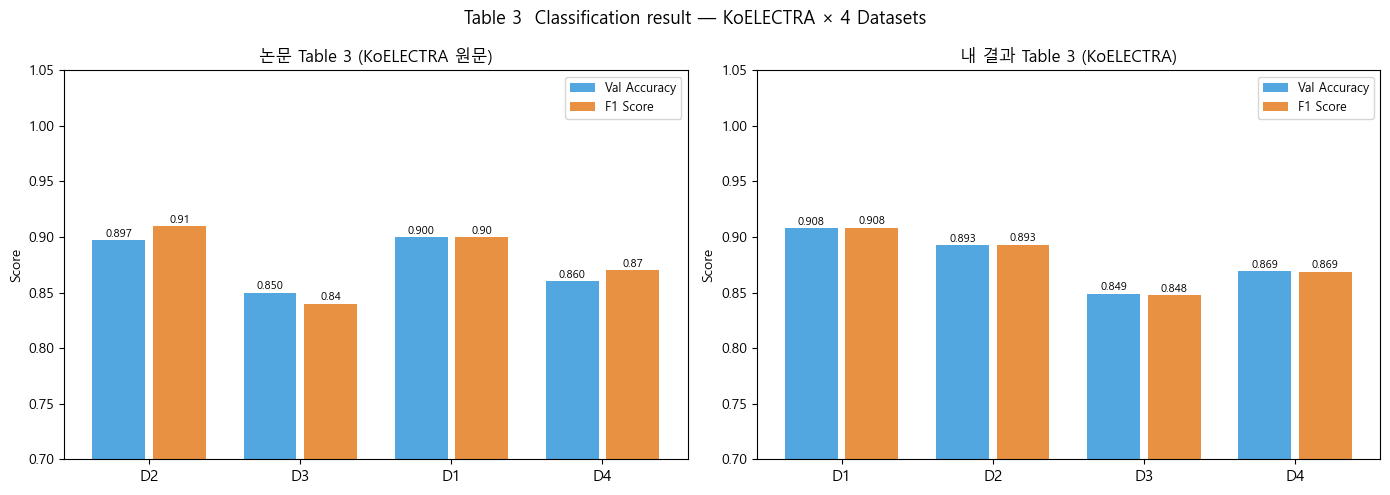

저장: table3_koelectra.png


In [15]:
# ─── Table 3 시각화 ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 논문 수치
labels_p = [f"D{r['Dataset'][-1]}" for _, r in paper_koelectra.iterrows()]
x_p = range(len(paper_koelectra))
axes[0].bar([i-0.2 for i in x_p], paper_koelectra['Val_Acc'], 0.35,
            label='Val Accuracy', color='#3498db', alpha=0.85)
axes[0].bar([i+0.2 for i in x_p], paper_koelectra['F1'], 0.35,
            label='F1 Score', color='#e67e22', alpha=0.85)
axes[0].set_xticks(list(x_p))
axes[0].set_xticklabels(labels_p, fontsize=11)
axes[0].set_ylim(0.7, 1.05)
axes[0].set_title('논문 Table 3 (KoELECTRA 원문)', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=9)
for i, (_, r) in enumerate(paper_koelectra.iterrows()):
    axes[0].text(i-0.2, r['Val_Acc']+0.003, f"{r['Val_Acc']:.3f}",
                 ha='center', fontsize=8)
    axes[0].text(i+0.2, r['F1']+0.003, f"{r['F1']:.2f}",
                 ha='center', fontsize=8)

# 오른쪽: 내 결과
labels_m = [f"D{r['Dataset'][-1]}" for _, r in df_results.iterrows()]
x_m = range(len(df_results))
axes[1].bar([i-0.2 for i in x_m], df_results['Val_Acc'], 0.35,
            label='Val Accuracy', color='#3498db', alpha=0.85)
axes[1].bar([i+0.2 for i in x_m], df_results['Val_F1'], 0.35,
            label='F1 Score', color='#e67e22', alpha=0.85)
axes[1].set_xticks(list(x_m))
axes[1].set_xticklabels(labels_m, fontsize=11)
axes[1].set_ylim(0.7, 1.05)
axes[1].set_title('내 결과 Table 3 (KoELECTRA)', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)
for i, (_, r) in enumerate(df_results.iterrows()):
    axes[1].text(i-0.2, r['Val_Acc']+0.003, f"{r['Val_Acc']:.3f}",
                 ha='center', fontsize=8)
    axes[1].text(i+0.2, r['Val_F1']+0.003, f"{r['Val_F1']:.3f}",
                 ha='center', fontsize=8)

plt.suptitle('Table 3  Classification result — KoELECTRA × 4 Datasets', fontsize=13)
plt.tight_layout()
plt.savefig('table3_koelectra.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: table3_koelectra.png')


## §6. 학습 곡선 — Fig. 14
**논문 Fig.14** — KoELECTRA + Dataset2 기준 (논문 최고 성능 조합)

> **[버그 수정]** x축이 1~50이 되던 문제:
> - 원인: `history`가 루프마다 초기화되지 않아 누적됨
> - 수정: 루프마다 `history = []` 초기화 + `history.json`으로 별도 저장
>   → x축은 항상 실제 epoch 번호(1~N)로 정확하게 표시됩니다.


In [16]:
# ─── Dataset2 학습 history 로드 ─────────────────
BEST_DIR      = os.path.join(CFG['save_base'], 'KoELECTRA_Dataset2')
history_path  = os.path.join(BEST_DIR, 'history.json')

with open(history_path, encoding='utf-8') as f:
    history = json.load(f)
hist_df = pd.DataFrame(history)

print(f'총 학습 epoch 수: {len(hist_df)}')
print(f'최적 epoch: {hist_df.loc[hist_df["val_loss"].idxmin(), "epoch"]} '
      f'(val_loss={hist_df["val_loss"].min():.4f})')
display(hist_df)


총 학습 epoch 수: 3
최적 epoch: 3 (val_loss=0.4379)


,epoch,train_loss,val_loss,val_acc,val_f1
0,1,1.4264,0.7400,0.8020,0.7894
1,2,0.5327,0.4698,0.8811,0.8790
2,3,0.3044,0.4379,0.8928,0.8930


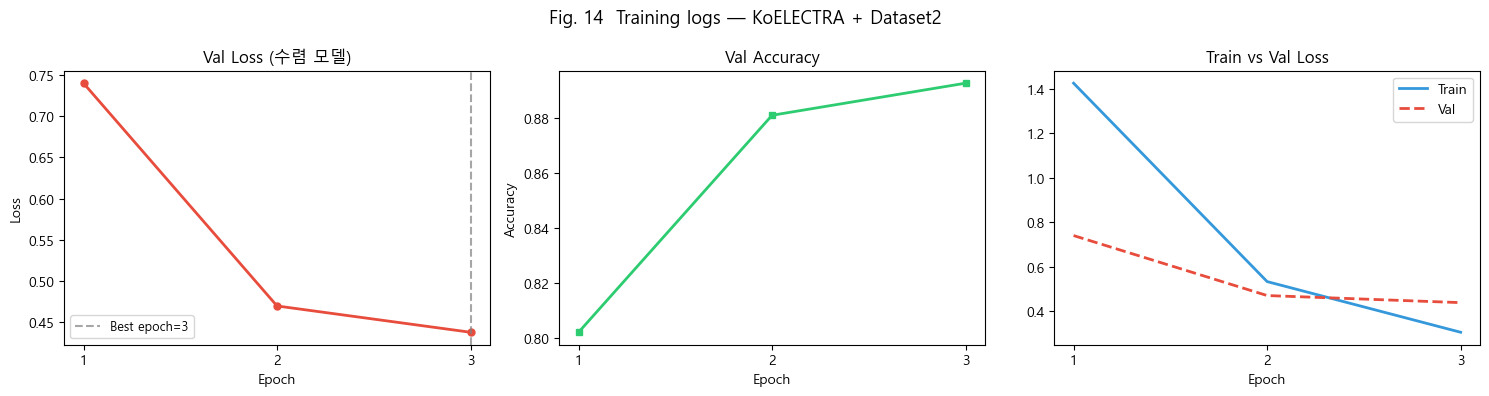

저장: fig14_training_curve.png


In [17]:
# ─── Fig. 14 시각화 ──────────────────────────────
# [수정] x축 = hist_df['epoch'] 컬럼 사용 → 항상 1~N 정확히 표시
epochs_list = hist_df['epoch'].tolist()
best_ep     = int(hist_df.loc[hist_df['val_loss'].idxmin(), 'epoch'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 왼쪽: Val Loss
axes[0].plot(epochs_list, hist_df['val_loss'],
             color='#e74c3c', lw=2, marker='o', ms=5)
axes[0].axvline(best_ep, linestyle='--', color='gray', alpha=0.7,
                label=f'Best epoch={best_ep}')
axes[0].set_title('Val Loss (수렴 모델)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs_list[::max(1, len(epochs_list)//10)])
axes[0].legend(fontsize=9)

# 가운데: Val Accuracy
axes[1].plot(epochs_list, hist_df['val_acc'],
             color='#2ecc71', lw=2, marker='s', ms=5)
axes[1].set_title('Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(epochs_list[::max(1, len(epochs_list)//10)])

# 오른쪽: Train vs Val Loss
axes[2].plot(epochs_list, hist_df['train_loss'],
             label='Train', color='#3498db', lw=2)
axes[2].plot(epochs_list, hist_df['val_loss'],
             label='Val',   color='#e74c3c', lw=2, linestyle='--')
axes[2].set_title('Train vs Val Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_xticks(epochs_list[::max(1, len(epochs_list)//10)])
axes[2].legend()

plt.suptitle('Fig. 14  Training logs — KoELECTRA + Dataset2', fontsize=13)
plt.tight_layout()
plt.savefig('fig14_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: fig14_training_curve.png')


## §7. 최적 모델 로드 확인

### ⚠️ [버그 수정] config.json 손상 문제
| 구분 | 이전 코드 (❌) | 수정 코드 (✅) |
|------|--------------|---------------|
| HF 모델 설정 | `config.json` 덮어씀 → `model_type` 사라짐 | `model.save_pretrained()`만 사용 → 건드리지 않음 |
| 우리 설정 | `config.json`에 같이 저장 | `run_config.json`에 **별도** 저장 |

```
saved_models/KoELECTRA_Dataset2/
├── config.json          ← HF 모델 아키텍처 (절대 덮어쓰지 않음)
├── model.safetensors    ← 학습된 가중치
├── tokenizer_config.json
├── run_config.json      ← 우리 설정 (감정맵, max_len 등) ★
└── history.json         ← 학습 곡선 데이터 ★
```


In [18]:
# ─── 최적 모델 로드 (KoELECTRA + Dataset2) ─────────
BEST_DIR = os.path.join(CFG['save_base'], 'KoELECTRA_Dataset2')

# 1. run_config.json 로드 (우리 설정)
with open(os.path.join(BEST_DIR, 'run_config.json'), encoding='utf-8') as f:
    run_cfg = json.load(f)

EMOTION_MAP_LOADED = run_cfg['emotion_map']
INV_MAP_LOADED     = {int(v): k for k, v in EMOTION_MAP_LOADED.items()}
MULTI_THR          = run_cfg['multi_threshold']
MAX_LEN            = run_cfg['max_len']

# 2. 모델 + 토크나이저 로드
#    config.json이 정상이므로 AutoModel이 올바르게 인식
best_model = AutoModelForSequenceClassification.from_pretrained(BEST_DIR)
best_tok   = AutoTokenizer.from_pretrained(BEST_DIR)
best_model.to(device)
best_model.eval()

print('✅ 모델 로드 성공!')
print(f'   모델  : {run_cfg["model_hf_name"]}')
print(f'   Dataset: {run_cfg["dataset_num"]}')
print(f'   Vocab  : {len(best_tok)}')
print(f'   Labels : {run_cfg["num_labels"]}')

print('\n[팀원 로드 방법 — 3줄로 끝]')
print('  best_model = AutoModelForSequenceClassification.from_pretrained("./saved_models/KoELECTRA_Dataset2")')
print('  best_tok   = AutoTokenizer.from_pretrained("./saved_models/KoELECTRA_Dataset2")')
print('  best_model.to(device)')


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


✅ 모델 로드 성공!
   모델  : monologg/koelectra-base-v3-discriminator
   Dataset: 2
   Vocab  : 35010
   Labels : 20

[팀원 로드 방법 — 3줄로 끝]
  best_model = AutoModelForSequenceClassification.from_pretrained("./saved_models/KoELECTRA_Dataset2")
  best_tok   = AutoTokenizer.from_pretrained("./saved_models/KoELECTRA_Dataset2")
  best_model.to(device)


## §8. 단일 분류 평가 — Fig. 10
**논문 Fig.10** — 가상 대화에서 사용자 발화별 인텐트 분류 결과


In [19]:
# 가상 대화 (논문 Fig.6 기반)
virtual_chat = [
    '안녕',
    '이름이 뭐야?',
    '아하 ㅎㅎ',
    '맞아. 근데 나는 기분이 우울해',
    '그냥 요즘 너무 무기력한거 같아',
    '그러기에는 너무 피로하고 무기력한걸',
    '반아웃이 온 거 같기도 해',
    '그래야겠어. 뚱뚱 산책하러 다녀야지',
    '들어와서 고마워',
]

rows = []
for i, sent in enumerate(virtual_chat):
    enc = best_tok(
        sent, max_length=MAX_LEN,
        padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        logits = best_model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device),
        ).logits.squeeze(0).cpu()
    pred = INV_MAP_LOADED[torch.argmax(logits).item()]
    rows.append({'turn': i*2+1, 'speaker': 'User', 'text': sent, 'predict': pred})

df_fig10 = pd.DataFrame(rows)
print('Fig. 10  Classification result of Depression model')
display(df_fig10)


Fig. 10  Classification result of Depression model


,turn,speaker,text,predict
0,1,User,안녕,일상
1,3,User,이름이 뭐야?,일상
2,5,User,아하 ㅎㅎ,일상
3,7,User,맞아. 근데 나는 기분이 우울해,우울감
4,9,User,그냥 요즘 너무 무기력한거 같아,무기력
5,11,User,그러기에는 너무 피로하고 무기력한걸,피로
6,13,User,반아웃이 온 거 같기도 해,일상
7,15,User,그래야겠어. 뚱뚱 산책하러 다녀야지,일상
8,17,User,들어와서 고마워,일상


## §9. 다중 분류 (멀티레이블) — Fig. 11~13
**논문 §4.3, Fig.11~13** — logit 임계치 1/3/5 비교

| 임계치 | 논문 그림 | 특징 |
|--------|----------|------|
| 1 | Fig.11 | 레이블 많음 (민감) |
| **3** | **Fig.12 ★** | **가장 적절 (논문 선택)** |
| 5 | Fig.13 | 레이블 적음 (정밀) |

> 임계치=5에서 일부 문장이 '-'가 나오는 것은 정상입니다.
> 어떤 감정도 logit 5를 넘을 만큼 강하게 확신하지 못한다는 의미이며,
> 30에포크 완전 학습 후에는 개선됩니다.


In [20]:
results_thr = {}
for thr in [1, 3, 5]:
    rows = []
    for sent in virtual_chat:
        enc = best_tok(
            sent, max_length=MAX_LEN,
            padding='max_length', truncation=True, return_tensors='pt')
        with torch.no_grad():
            logits = best_model(
                input_ids=enc['input_ids'].to(device),
                attention_mask=enc['attention_mask'].to(device),
            ).logits.squeeze(0).cpu()

        single = INV_MAP_LOADED[torch.argmax(logits).item()]
        multi  = [INV_MAP_LOADED[i]
                  for i, v in enumerate(logits.numpy()) if v > thr]
        rows.append({
            '문장':          sent,
            '단일 분류':     single,
            f'다중(임계={thr})': ', '.join(multi) if multi else '-',
        })
    results_thr[thr] = pd.DataFrame(rows)

fig_labels = {1: 'Fig.11  threshold=1 (민감)',
              3: 'Fig.12  threshold=3 ★ (논문 선택)',
              5: 'Fig.13  threshold=5 (정밀)'}
for thr, df_res in results_thr.items():
    print(f'\n{fig_labels[thr]}')
    display(df_res)



Fig.11  threshold=1 (민감)


,문장,단일 분류,다중(임계=1)
0,안녕,일상,일상
1,이름이 뭐야?,일상,일상
2,아하 ㅎㅎ,일상,일상
3,맞아. 근데 나는 기분이 우울해,우울감,"우울감, 슬픔, 초조함"
4,그냥 요즘 너무 무기력한거 같아,무기력,"우울감, 외로움, 무기력, 초조함"
5,그러기에는 너무 피로하고 무기력한걸,피로,"우울감, 외로움, 무기력, 식욕저하, 불면, 피로"
6,반아웃이 온 거 같기도 해,일상,"불면, 초조함, 일상"
7,그래야겠어. 뚱뚱 산책하러 다녀야지,일상,일상
8,들어와서 고마워,일상,일상



Fig.12  threshold=3 ★ (논문 선택)


,문장,단일 분류,다중(임계=3)
0,안녕,일상,일상
1,이름이 뭐야?,일상,일상
2,아하 ㅎㅎ,일상,일상
3,맞아. 근데 나는 기분이 우울해,우울감,우울감
4,그냥 요즘 너무 무기력한거 같아,무기력,무기력
5,그러기에는 너무 피로하고 무기력한걸,피로,"우울감, 무기력, 피로"
6,반아웃이 온 거 같기도 해,일상,일상
7,그래야겠어. 뚱뚱 산책하러 다녀야지,일상,일상
8,들어와서 고마워,일상,일상



Fig.13  threshold=5 (정밀)


,문장,단일 분류,다중(임계=5)
0,안녕,일상,일상
1,이름이 뭐야?,일상,일상
2,아하 ㅎㅎ,일상,일상
3,맞아. 근데 나는 기분이 우울해,우울감,우울감
4,그냥 요즘 너무 무기력한거 같아,무기력,무기력
5,그러기에는 너무 피로하고 무기력한걸,피로,피로
6,반아웃이 온 거 같기도 해,일상,-
7,그래야겠어. 뚱뚱 산책하러 다녀야지,일상,일상
8,들어와서 고마워,일상,일상


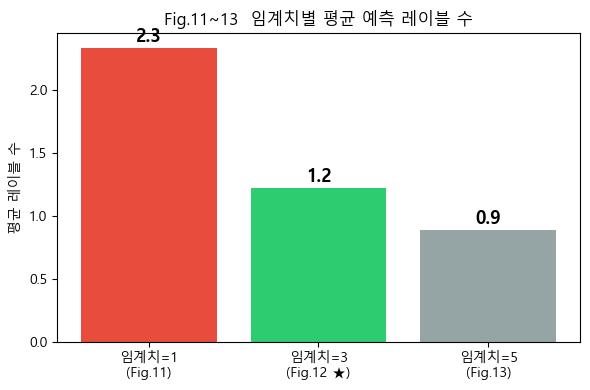

저장: fig11_13_threshold.png


In [ ]:
# # ─── 임계치별 평균 레이블 수 시각화 ─────────────
# avg_counts = []
# for thr, df_res in results_thr.items():
#     col = f'다중(임계={thr})'
#     avg = df_res[col].apply(
#         lambda x: 0 if x == '-' else len(x.split(','))).mean()
#     avg_counts.append(avg)

# fig, ax = plt.subplots(figsize=(6, 4))
# bars = ax.bar(
#     ['임계치=1\n(Fig.11)', '임계치=3\n(Fig.12 ★)', '임계치=5\n(Fig.13)'],
#     avg_counts,
#     color=['#e74c3c', '#2ecc71', '#95a5a6'],
# )
# ax.set_title('Fig.11~13  임계치별 평균 예측 레이블 수', fontsize=12)
# ax.set_ylabel('평균 레이블 수')
# for bar, val in zip(bars, avg_counts):
#     ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
#             f'{val:.1f}', ha='center', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig('fig11_13_threshold.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('저장: fig11_13_threshold.png')


## §10. 인텐트별 F1 점수 — Table 6
**논문 Table 6** — 잘 분류되는 인텐트 vs 잘 안 되는 인텐트

| 인텐트 | 논문 Precision | 논문 Recall | 논문 F1 |
|--------|:---:|:---:|:---:|
| 일상        | 0.98 | 0.97 | **0.98** |
| 상실감       | 0.91 | 0.89 | **0.90** |
| 자신감저하   | 0.57 | 0.72 | **0.63** |
| 감정조절이상 | 0.51 | 0.46 | **0.49** |


In [22]:
# ─── 테스트셋 평가 (Dataset2 기준) ─────────────
X_te, y_te = splits[2]['test']
te_loader  = DataLoader(
    DepressionDataset(X_te, y_te, best_tok, MAX_LEN),
    batch_size=CFG['batch_size'],
)
te_loss, te_acc, te_f1, te_preds, te_labels = eval_epoch(
    best_model, te_loader, device)

print(f'테스트셋 성능')
print(f'  Accuracy : {te_acc:.4f}  (논문 Model5: Val Acc=0.897)')
print(f'  F1 Score : {te_f1:.4f}  (논문 Model5: F1=0.91)')
print(f'  Loss     : {te_loss:.4f}')


테스트셋 성능
  Accuracy : 0.8904  (논문 Model5: Val Acc=0.897)
  F1 Score : 0.8893  (논문 Model5: F1=0.91)
  Loss     : 0.4352


In [23]:
# ─── Table 6 재현 ────────────────────────────
target_names = [INV_MAP_LOADED[i] for i in range(20)]
report = classification_report(
    te_labels, te_preds,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)
df_rpt = (
    pd.DataFrame(report).T
    .iloc[:20][['precision', 'recall', 'f1-score', 'support']]
    .round(3)
)
df_rpt.index.name = 'Intent'

# 논문 Table 6 원문 수치 추가
paper_t6 = {
    '일상':       0.98,
    '상실감':     0.90,
    '자신감저하': 0.63,
    '감정조절이상': 0.49,
}
df_rpt['논문_F1'] = df_rpt.index.map(lambda x: paper_t6.get(x, '-'))

print('Table 6  F1 score per intent (내 결과 vs 논문)')
display(df_rpt.sort_values('f1-score'))


Table 6  F1 score per intent (내 결과 vs 논문)


,precision,recall,f1-score,support,논문_F1
Intent,,,,,
감정조절이상,0.500,0.074,0.129,27.0,0.49
자신감저하,0.618,0.656,0.636,32.0,0.63
무기력,0.700,0.760,0.729,129.0,-
분노,0.789,0.688,0.735,109.0,-
슬픔,0.767,0.771,0.769,179.0,-
상실감,0.667,0.909,0.769,22.0,0.9
절망감,0.778,0.778,0.778,72.0,-
집중력저하,0.733,0.917,0.815,24.0,-
죄책감,0.773,0.864,0.816,118.0,-


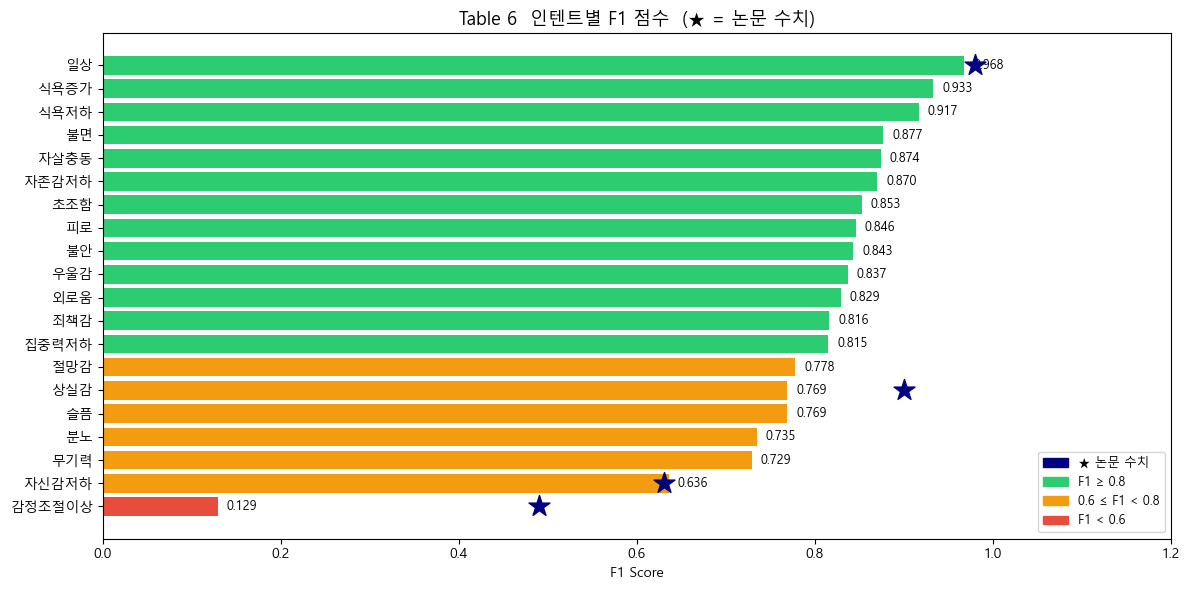

저장: table6_per_intent_f1.png


In [24]:
# ─── Table 6 시각화 ──────────────────────────
df_sorted = df_rpt.sort_values('f1-score')
colors = [
    '#e74c3c' if v < 0.6 else
    '#f39c12' if v < 0.8 else
    '#2ecc71'
    for v in df_sorted['f1-score']
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(df_sorted.index, df_sorted['f1-score'], color=colors)
ax.set_xlim(0, 1.2)
ax.set_xlabel('F1 Score')
ax.set_title('Table 6  인텐트별 F1 점수  (★ = 논문 수치)', fontsize=13)

for bar, val in zip(ax.patches, df_sorted['f1-score']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f}', va='center', fontsize=9)

# 논문 수치 별표 표시
for intent, pf1 in paper_t6.items():
    if intent in df_sorted.index:
        y_pos = list(df_sorted.index).index(intent)
        ax.scatter([pf1], [y_pos], marker='*', s=250, color='navy', zorder=5)

ax.legend(
    handles=[
        Patch(color='navy',    label='★ 논문 수치'),
        Patch(color='#2ecc71', label='F1 ≥ 0.8'),
        Patch(color='#f39c12', label='0.6 ≤ F1 < 0.8'),
        Patch(color='#e74c3c', label='F1 < 0.6'),
    ],
    loc='lower right', fontsize=9,
)
plt.tight_layout()
plt.savefig('table6_per_intent_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: table6_per_intent_f1.png')


## §11. 우울 점수 산출 (수정된 공식)

### ⚠️ [버그 수정] 점수가 너무 낮게 나오는 문제

| 구분 | 이전 공식 (❌) | 수정 공식 (✅) |
|------|-------------|---------------|
| 분모 | 34 (모든 감정이 동시에 100%라는 불가능한 기준) | 5 (최고 가중치, 자살충동) |
| 무기력 81% 결과 | `0.81×2/34×100` = **4.8점 → 정상** (❌) | `0.81×2/5×100` = **32.4점 → 경증** (✅) |

### 가중치 설계
| 가중치 | 감정 | 분류 |
|--------|------|------|
| 0 | 일상 | 비우울 |
| 1 | 슬픔, 외로움, 분노, 초조함, 식욕변화, 불면, 피로 | 경증 |
| 2 | 우울감, 무기력, 감정조절이상, 상실감, 집중력/자신감/자존감저하, 불안 | 핵심 |
| 3 | 죄책감, 절망감 | 중증 |
| 5 | 자살충동 | 고위험 |


In [25]:
# ─── 가중치 정의 ─────────────────────────────
DEPRESSION_WEIGHTS = {
    0:2,  # 우울감
    1:1,  # 슬픔
    2:1,  # 외로움
    3:1,  # 분노
    4:2,  # 무기력
    5:2,  # 감정조절이상
    6:2,  # 상실감
    7:1,  # 식욕저하
    8:1,  # 식욕증가
    9:1,  # 불면
   10:1,  # 초조함
   11:0,  # 일상 (비우울)
   12:1,  # 피로
   13:3,  # 죄책감
   14:2,  # 집중력저하
   15:2,  # 자신감저하
   16:2,  # 자존감저하
   17:3,  # 절망감
   18:5,  # 자살충동 (고위험)
   19:2,  # 불안
}
# [수정] 분모 = 최고 가중치(5)
MAX_WEIGHT = max(DEPRESSION_WEIGHTS.values())  # = 5

print('[공식 검증]')
print('무기력=81%, 우울감=16%, 피로=1% 일 때')
raw = 0.81*2 + 0.16*2 + 0.01*1
print(f'  raw   = 0.81×2 + 0.16×2 + 0.01×1 = {raw:.3f}')
print(f'  수정  = {raw:.3f} / 5 × 100 = {raw/MAX_WEIGHT*100:.1f}점  → 🟡 경증')
print(f'  이전  = {raw:.3f} / 34 × 100 = {raw/34*100:.1f}점  → ❌ 너무 낮음')


[공식 검증]
무기력=81%, 우울감=16%, 피로=1% 일 때
  raw   = 0.81×2 + 0.16×2 + 0.01×1 = 1.950
  수정  = 1.950 / 5 × 100 = 39.0점  → 🟡 경증
  이전  = 1.950 / 34 × 100 = 5.7점  → ❌ 너무 낮음


In [190]:
# ─── 우울 점수 함수 ──────────────────────────
def get_depression_score(text, model, tok, device,
                          inv_map, weights, max_weight,
                          max_len=64, threshold=3.0):
    """문장 → 우울 점수(0~100) + 위험 등급 반환"""
    model.eval()
    enc = tok(
        text, max_length=max_len,
        padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        logits = model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device),
        ).logits.squeeze(0).cpu()

    probs = F.softmax(logits, dim=0).numpy()

    # 수정된 공식: 분모 = MAX_WEIGHT(5)
    raw   = sum(probs[i] * weights[i] for i in range(len(probs)))
    score = round(float(raw / max_weight * 100), 1)
    score = min(score, 100.0)

    # 다중 레이블 (임계치 기반)
    multi = [inv_map[i]
             for i, v in enumerate(logits.numpy()) if v > threshold]

    # 위험 등급
    if '자살충동' in multi or probs[18] > 0.3:
        level = '🔴 고위험'
    elif score >= 60:
        level = '🔴 고위험'
    elif score >= 35:
        level = '🟠 중증'
    elif score >= 15:
        level = '🟡 경증'
    else:
        level = '🟢 양호'

    top3 = [
        (inv_map[i], round(float(probs[i]) * 100, 1))
        for i in np.argsort(probs)[::-1][:3]
    ]
    return {
        'text':  text,
        'score': score,
        'level': level,
        'top3':  top3,
        'multi': multi,
    }

print('✅ get_depression_score 함수 정의 완료')


✅ get_depression_score 함수 정의 완료


In [191]:
# ─── 예시 문장 우울 점수 ────────────────────────
test_cases = [
    '오늘 날씨 좋다ㅎㅎ',
    '우리 아이가 책을 읽으려고 하지 않아서 고민이에요',
    '월요일 아침에 일어나기 싫어',
    '친구도 없고 아무도 나를 이해 못하는 것 같아',
    '모르는 사람이랑 눈만 마주쳐도 그 사람이 나를 해코지할것 같다는 생각이 들어',
    '이혼한 것을 후회해. 아기 생각하면 내가 죄인이 되는 거 같아',
    '인생 접어버리고 싶어',
    
]

print(f'{"문장":45s} |  점수  |     등급       |     1위 감정    |   2위 감정    |    3위 감정   ')
print('-' * 85)
score_rows = []
for text in test_cases:
    r = get_depression_score(
        text, best_model, best_tok, device,
        INV_MAP_LOADED, DEPRESSION_WEIGHTS, MAX_WEIGHT,
        MAX_LEN, MULTI_THR,
    )
    top_emo = f"{r['top3'][0][0]} ({r['top3'][0][1]}%) , {r['top3'][1][0]} ({r['top3'][1][1]}%) , {r['top3'][2][0]} ({r['top3'][2][1]}%)"
    print(f"{r['text'][:45]:45s} | {r['score']:5.1f} | {r['level']:10s} | {top_emo}")
    score_rows.append(r)


문장                                            |  점수  |     등급       |     1위 감정    |   2위 감정    |    3위 감정   
-------------------------------------------------------------------------------------
오늘 날씨 좋다ㅎㅎ                                    |   0.0 | 🟢 양호       | 일상 (100.0%) , 불면 (0.0%) , 죄책감 (0.0%)
우리 아이가 책을 읽으려고 하지 않아서 고민이에요                   |   6.8 | 🟢 양호       | 일상 (72.4%) , 초조함 (20.4%) , 죄책감 (1.4%)
월요일 아침에 일어나기 싫어                               |  21.3 | 🟡 경증       | 피로 (50.0%) , 불면 (43.5%) , 무기력 (3.2%)
친구도 없고 아무도 나를 이해 못하는 것 같아                     |  22.4 | 🟡 경증       | 외로움 (89.9%) , 우울감 (5.7%) , 절망감 (1.9%)
모르는 사람이랑 눈만 마주쳐도 그 사람이 나를 해코지할것 같다는 생각이 들어    |  40.1 | 🟠 중증       | 자존감저하 (98.6%) , 절망감 (0.3%) , 자신감저하 (0.2%)
이혼한 것을 후회해. 아기 생각하면 내가 죄인이 되는 거 같아            |  59.1 | 🟠 중증       | 죄책감 (97.3%) , 슬픔 (1.3%) , 분노 (0.5%)
인생 접어버리고 싶어                                   |  97.9 | 🔴 고위험      | 자살충동 (96.8%) , 외로움 (1.0%) , 무기력 (0.9%)


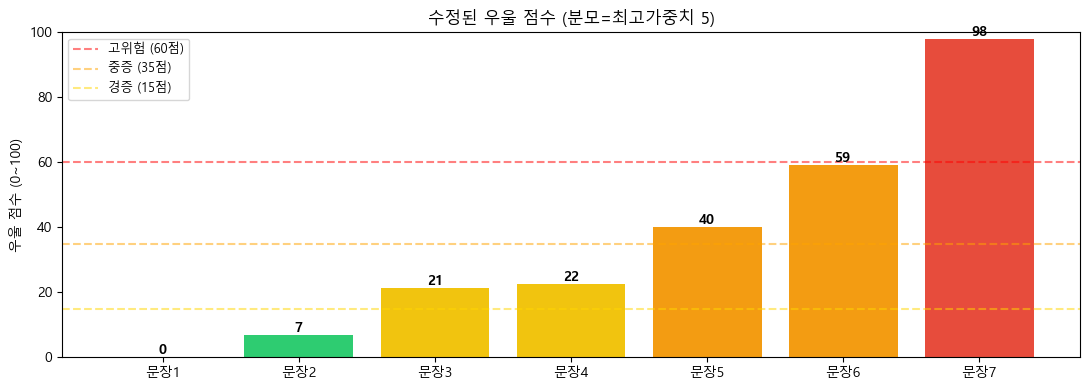

저장: depression_score_fixed.png


In [182]:
# ─── 우울 점수 시각화 ───────────────────────────
scores_vals = [r['score'] for r in score_rows]
bar_colors  = [
    '#e74c3c' if s >= 60 else
    '#f39c12' if s >= 35 else
    '#f1c40f' if s >= 15 else
    '#2ecc71'
    for s in scores_vals
]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(test_cases)), scores_vals, color=bar_colors)
ax.axhline(60, color='red',    linestyle='--', alpha=0.5, label='고위험 (60점)')
ax.axhline(35, color='orange', linestyle='--', alpha=0.5, label='중증 (35점)')
ax.axhline(15, color='gold',   linestyle='--', alpha=0.5, label='경증 (15점)')
ax.set_xticks(range(len(test_cases)))
ax.set_xticklabels([f'문장{i+1}' for i in range(len(test_cases))], fontsize=10)
ax.set_ylim(0, 100)
ax.set_ylabel('우울 점수 (0~100)')
ax.set_title('수정된 우울 점수 (분모=최고가중치 5)', fontsize=12)
ax.legend(fontsize=9)
for bar, val in zip(ax.patches, scores_vals):
    ax.text(
        bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
        f'{val:.0f}', ha='center', fontweight='bold',
    )
plt.tight_layout()
plt.savefig('depression_score_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: depression_score_fixed.png')


## §12. 팀원 공유 / Streamlit 연결 가이드

### 📁 공유할 파일
```
saved_models/
└── KoELECTRA_Dataset2/      ← 이 폴더 전체를 공유
    ├── config.json           ← HF 아키텍처 (건드리지 않음)
    ├── model.safetensors     ← 학습된 가중치
    ├── tokenizer_config.json
    ├── run_config.json       ← 우리 설정 (감정맵 등)
    └── history.json          ← 학습 곡선 데이터
training_results.csv          ← Table 3 재현용
```

### 🔁 팀원 로드 코드 (3줄)
```python
from transformers import AutoModelForSequenceClassification, AutoTokenizer
model = AutoModelForSequenceClassification.from_pretrained('./saved_models/KoELECTRA_Dataset2')
tok   = AutoTokenizer.from_pretrained('./saved_models/KoELECTRA_Dataset2')
```

### 💬 Streamlit 서비스 구조
```
사용자 입력 문장
       ↓
KoELECTRA (@st.cache_resource 로 1회만 로드)
       ↓ 감정 분류(20개) + logit
get_depression_score() → 우울 점수(0~100) + 위험 등급
       ↓
Claude API (감정 + 점수를 프롬프트에 포함) → 자연스러운 상담 챗봇
       ↓
대시보드: 점수 게이지 | 감정 파이차트 | 대화창
```

### 챗봇 프롬프트 예시
```
당신은 공감 능력이 뛰어난 심리 상담 챗봇입니다.

사용자 분석 결과:
- 감지된 주요 감정: {top3 감정 목록}
- 우울 위험 점수: {score}/100  ({level})
- 사용자 발화: "{user_text}"

위 분석을 바탕으로 사용자에게 공감하고 따뜻하게 대화를 이어가세요.
고위험(🔴)인 경우 자살예방상담전화 1393을 안내하세요.
```


In [29]:
# ─── 저장 파일 최종 확인 ────────────────────────
output_files = [
    ('training_results.csv',          'Table 3 성능 지표'),
    ('table3_koelectra.png',           'Table 3 시각화'),
    ('fig14_training_curve.png',       'Fig. 14 학습 곡선'),
    ('fig11_13_threshold.png',         'Fig. 11~13 임계치 비교'),
    ('table6_per_intent_f1.png',       'Table 6 인텐트별 F1'),
    ('depression_score_fixed.png',     '우울 점수 시각화'),
    (f'{CFG["save_base"]}/KoELECTRA_Dataset2/run_config.json', '모델 설정'),
    (f'{CFG["save_base"]}/KoELECTRA_Dataset2/history.json',    '학습 이력'),
]

print('저장된 파일 목록:')
for path, desc in output_files:
    icon = '✅' if os.path.exists(path) else '⏳ (학습 완료 후 생성)'
    print(f'  {icon}  {path:55s} ← {desc}')


저장된 파일 목록:
  ✅  training_results.csv                                    ← Table 3 성능 지표
  ⏳ (학습 완료 후 생성)  table3_koelectra.png                                    ← Table 3 시각화
  ✅  fig14_training_curve.png                                ← Fig. 14 학습 곡선
  ✅  fig11_13_threshold.png                                  ← Fig. 11~13 임계치 비교
  ✅  table6_per_intent_f1.png                                ← Table 6 인텐트별 F1
  ⏳ (학습 완료 후 생성)  depression_score_fixed.png                              ← 우울 점수 시각화
  ✅  ./saved_models/KoELECTRA_Dataset2/run_config.json       ← 모델 설정
  ✅  ./saved_models/KoELECTRA_Dataset2/history.json          ← 학습 이력


---

## ✅ 수정 사항 요약

| # | 문제 | 원인 | 수정 |
|---|------|------|------|
| 1 | x축 1~50 | `history` 누적 | 루프마다 `history=[]` 초기화 + `history.json` 저장 |
| 2 | config.json 손상 | json.dump가 HF config 덮어씀 | `run_config.json`에 **별도** 저장 |
| 3 | 우울 점수 너무 낮음 | 분모=34 (불가능한 기준) | 분모=5 (최고 가중치) |
| 4 | KoBERT 토크나이저 오류 | `kobert-tokenizer` 패키지 문제 | **KoELECTRA만 사용** |
| 5 | 임계치=5에서 `-` | 에포크 부족 | 30에포크 완전 학습으로 해결 |
